# Figure1 

## Overlay 2D keypoint trajectories on the first frame of a time interval


In [68]:
"""
Data loading for 2D keypoint overlay visualization.
Run this cell once, then iterate on the visualization cell below.
"""

from pathlib import Path
import csv
import json
from typing import List, Dict, Tuple, Optional
import numpy as np
import cv2

# =====================================================================
# DATA CONFIG
# =====================================================================

# Directories
# =============================================
# # walking videos 
# VIDEO_DIR = Path("/mnt/lemebel/happyhouse_102025/session6/2025_10_12_15_06_46/videos/")
# CSV_DIR   = Path("/mnt/lemebel/happyhouse_102025/session6/2025_10_12_15_06_46/videos/predictions/2025_12_12_15_05_35/")
# FIG_DIR   = Path("/mnt/lemebel/happyhouse_102025/session6/2025_10_12_15_06_46/figures")
# FRAME_START = 137600
# FRAME_END   = 138400

# =============================================
# # courtship videos
# VIDEO_DIR = Path("/home/user/red_data/courtship_videos/2025_10_20_13_20_04/videos/")
# CSV_DIR   = Path("/home/user/red_data/courtship_videos/2025_10_20_13_20_04/videos/labeled_data/2026_02_13_10_49_27/")
# FIG_DIR   = Path("/home/user/red_data/courtship_videos/2025_10_20_13_20_04/videos/figures")
# FRAME_START = 149573
# FRAME_END   = 149588

# # Staircase videos
# VIDEO_DIR = Path("/home/user/red_data/stairs_videos/2026_01_12_14_07_16/")
# CSV_DIR   = Path("/home/user/red_data/stairs_videos/2026_01_12_14_07_16/labeled_data/2026_02_15_18_03_13/")
# FIG_DIR   = Path("/home/user/red_data/stairs_videos/2026_01_12_14_07_16/figures")
# FRAME_START = 24209
# FRAME_END   = 24321

# headless BDN2 videos 
VIDEO_DIR = Path("/media/user/LaCie2/Session7/2025_10_13_18_22_50/")
CSV_DIR   = Path("/media/user/LaCie2/Session7/2025_10_13_18_22_50/labeled_data/2026_04_15_12_11_09/")
FIG_DIR   = Path("/home/user/3D_tracking_paper/output/BDN2 headless/")
FRAME_START = 350

FRAME_END   = 3700

# Camera selection — set to a camera stem (e.g. "Cam2012862") or None for first found
CAMERA_NAME = 'Cam2012861'

# Keypoints to plot (for trajectory overlay)
KP_NAMES = ["T1L_TaTip"]

# =====================================================================
# LOADING FUNCTIONS
# =====================================================================

def load_skeleton_from_csv_header(csv_path: Path):
    with csv_path.open("r", encoding="utf-8") as f:
        first_line = f.readline().strip()
    skel_path = Path(first_line).expanduser()
    if not skel_path.is_file():
        skel_path = (csv_path.parent / first_line).resolve()
        if not skel_path.is_file():
            print(f"[WARNING] Skeleton JSON not found: '{first_line}'")
            return None, None, None
    try:
        with skel_path.open("r", encoding="utf-8") as f:
            skel = json.load(f)
        names = skel.get("node_names", None)
        edges = skel.get("edges", None)
        return (skel_path,
                names if isinstance(names, list) else None,
                edges if isinstance(edges, list) else None)
    except Exception as e:
        print(f"[WARNING] Failed to load skeleton: {e}")
        return skel_path, None, None


def load_keypoints2d(csv_path: Path, not_assigned_threshold: float = 1e6):
    skel_path, node_names, edges = load_skeleton_from_csv_header(csv_path)
    with csv_path.open("r", encoding="utf-8") as f:
        lines = f.read().splitlines()
    if len(lines) < 2:
        raise ValueError(f"{csv_path} has no data rows.")
    first_data_row = next(csv.reader([lines[1]]))
    n_fields = len(first_data_row)
    if (n_fields - 1) % 3 != 0:
        raise ValueError(f"Unexpected column count ({n_fields})")
    n_kp = (n_fields - 1) // 3

    frames, all_pts = [], []
    for raw in lines[1:]:
        if not raw.strip():
            continue
        row = next(csv.reader([raw]))
        fid = int(row[0])
        frames.append(fid)
        kp = np.full((n_kp, 2), np.nan)
        for i in range(n_kp):
            base = 1 + 3 * i
            kid, x, y = int(row[base]), float(row[base+1]), float(row[base+2])
            if abs(x) >= not_assigned_threshold or abs(y) >= not_assigned_threshold:
                x, y = np.nan, np.nan
            if 0 <= kid < n_kp:
                kp[kid] = [x, y]
        all_pts.append(kp)

    return np.array(frames), np.stack(all_pts), skel_path, node_names, edges


def resolve_keypoint_indices(node_names, kp_names):
    idxs, labels = [], []
    for name in (kp_names or []):
        idx = node_names.index(name)
        if idx not in idxs:
            idxs.append(idx)
            labels.append(name)
    return idxs, labels


def get_frame_mask(frames, frame_start, frame_end):
    mask = (frames >= frame_start) & (frames <= frame_end)
    if not np.any(mask):
        raise ValueError(
            f"No frames in [{frame_start}, {frame_end}]. "
            f"Available: {frames.min()}–{frames.max()}"
        )
    return mask


def read_frame(video_path: Path, frame_index: int):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
    ok, bgr = cap.read()
    cap.release()
    if not ok or bgr is None:
        raise RuntimeError(f"Could not read frame {frame_index}")
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def find_camera_pairs(video_dir: Path, csv_dir: Path):
    vexts = {".avi", ".mp4", ".mov", ".mkv"}
    vmap = {p.stem: p for p in video_dir.iterdir() if p.is_file() and p.suffix.lower() in vexts}
    cmap = {p.stem: p for p in csv_dir.iterdir() if p.is_file() and p.suffix.lower() == ".csv"}
    return [(s, vmap[s], cmap[s]) for s in sorted(set(vmap) & set(cmap))]


# =====================================================================
# LOAD DATA
# =====================================================================

pairs = find_camera_pairs(VIDEO_DIR, CSV_DIR)
if not pairs:
    raise RuntimeError("No camera/video pairs found — check VIDEO_DIR and CSV_DIR.")

if CAMERA_NAME:
    match = [(n, v, c) for n, v, c in pairs if n == CAMERA_NAME]
    if not match:
        raise ValueError(f"'{CAMERA_NAME}' not found. Available: {[n for n,_,_ in pairs]}")
    cam_name, video_path, csv_path = match[0]
else:
    cam_name, video_path, csv_path = pairs[0]
print(f"Camera: {cam_name}")

frames, points, _, node_names, edges = load_keypoints2d(csv_path)
kp_idxs, kp_labels = resolve_keypoint_indices(node_names, KP_NAMES)
mask = get_frame_mask(frames, FRAME_START, FRAME_END)
n_masked = int(np.sum(mask))
print(f"  Frames {FRAME_START}–{FRAME_END}  ({n_masked} frames)")

frame_rgb = read_frame(video_path, FRAME_START)
img_h, img_w = frame_rgb.shape[:2]
print(f"  Image: {img_w}×{img_h}")

Camera: Cam2012861
  Frames 350–3700  (3351 frames)
  Image: 1936×448


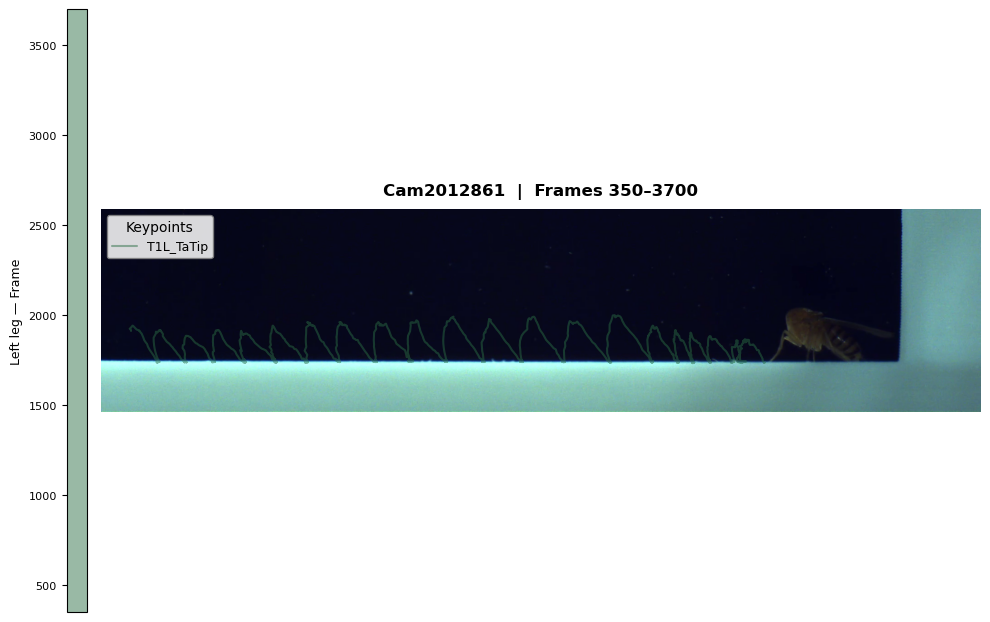

In [77]:
"""
Visualization: overlay 2D trajectories + skeleton on camera frame.
Re-run this cell to iterate — data is loaded in the cell above.
Saves SVG with each skeleton as a grouped object for Inkscape editing.
"""

from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap, Normalize
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

# =====================================================================
# VISUALIZATION CONFIG 
# =====================================================================

USE_TRIPOD_COLORS = True
POINTS_ONLY = False           # True = scatter dots, False = connected lines

# Skeleton overlay
SHOW_SKELETON_OVERLAY = False
SKELETON_EVERY_N_FRAMES =500    # draw skeleton every N frames within bout
SKELETON_JOINT_SIZE = 2.5        # joint marker diameter (points)
SKELETON_LINE_WIDTH = 1.2        # edge line width
SKELETON_ALPHA_START = 0.9       # transparency of oldest skeleton pose
SKELETON_ALPHA_END   = 0.9       # transparency of newest skeleton pose

# Body-part colors — easily editable dict
SKELETON_COLORS = {
    "body":  "#510455ED",  # gray
    "WingL": "#58B0FD",  # light blue
    "WingR": "#6B79D4",  # salmon
    "T1L":   "#0CE2DB",  # blue
    "T1R":   "#08CE0CC8",  # purple
    "T2L":   "#6FE60D",  # red
    "T2R":   "#E2BA1B",  # green
    "T3L":   "#F94B06",  # orange
    "T3R":   "#D10E0E",  # brown
}

# =====================================================================
# DRAWING FUNCTIONS
# =====================================================================

CMAP_tri1 = LinearSegmentedColormap.from_list("left",  ["#2a6d447a", "#2a6d447a"])
CMAP_tri2 = LinearSegmentedColormap.from_list("right", ["#E29911B6", "#E29911B6"])

def get_side_cmap(kp_name: str):
    if "T1L" in kp_name or "T3L" in kp_name or "T2R" in kp_name:
        return CMAP_tri1
    else:
        return CMAP_tri2


def classify_body_part(name: str) -> str:
    """Map a node name to a body-part key for coloring."""
    for prefix in ("T1L", "T1R", "T2L", "T2R", "T3L", "T3R"):
        if name.startswith(prefix):
            return prefix
    if name.startswith("WingL"):
        return "WingL"
    if name.startswith("WingR"):
        return "WingR"
    return "body"


def draw_skeleton_2d(ax, points_2d, edges, node_names, colors_dict,
                     alpha, lw, joint_size, img_h, gid_prefix=None):
    """Draw one skeleton frame using LineCollection + scatter.

    Each skeleton gets two artists (edges + joints) tagged with gid_prefix
    so they can be grouped in the SVG for Inkscape.
    """
    pts = points_2d.copy().astype(float)
    pts[:, 1] = img_h - 1 - pts[:, 1]

    # Edges as LineCollection (single SVG element)
    segments, edge_colors = [], []
    for i, j in edges:
        if i >= len(pts) or j >= len(pts):
            continue
        x0, y0 = pts[i]
        x1, y1 = pts[j]
        if np.isnan(x0) or np.isnan(y0) or np.isnan(x1) or np.isnan(y1):
            continue
        segments.append([(x0, y0), (x1, y1)])
        edge_colors.append(colors_dict.get(classify_body_part(node_names[i]), "#888888"))

    if segments:
        lc = LineCollection(segments, colors=edge_colors, linewidths=lw,
                            alpha=alpha, capstyle="round")
        if gid_prefix:
            lc.set_gid(f"{gid_prefix}_edges")
        ax.add_collection(lc)

    # Joints as scatter (single SVG element)
    jx, jy, jcolors = [], [], []
    for k in range(len(pts)):
        xk, yk = pts[k]
        if np.isnan(xk) or np.isnan(yk):
            continue
        jx.append(xk)
        jy.append(yk)
        jcolors.append(colors_dict.get(classify_body_part(node_names[k]), "#888888"))

    if jx:
        sc = ax.scatter(jx, jy, s=joint_size**2, c=jcolors, alpha=alpha, zorder=5, edgecolors='none')
        if gid_prefix:
            sc.set_gid(f"{gid_prefix}_joints")


def plot_trajectory(ax, x, y, *, label, cmap, lw=0.5, marker_size=2.5,
                    points_only=False):
    valid = ~np.isnan(x) & ~np.isnan(y)
    x, y = np.asarray(x)[valid], np.asarray(y)[valid]

    if len(x) < 2:
        return

    color = cmap(0.5)

    if points_only:
        ax.scatter(x, y, s=marker_size**2, c=[color] * len(x), edgecolors='none',
                   label=label, zorder=4)
    else:
        ax.plot(x, y, color=color, lw=lw, solid_capstyle='round',
                label=label, zorder=4)


def group_skeletons_in_svg(svg_path, frame_ids):
    """Post-process SVG to wrap each skeleton's elements in a <g> group.

    Each skeleton pose becomes a single selectable/deletable group in Inkscape,
    labeled 'Skeleton frame {fid}' in the Objects panel.
    """
    SVG_NS = 'http://www.w3.org/2000/svg'
    INKSCAPE_NS = 'http://www.inkscape.org/namespaces/inkscape'
    ET.register_namespace('', SVG_NS)
    ET.register_namespace('xlink', 'http://www.w3.org/1999/xlink')
    ET.register_namespace('inkscape', INKSCAPE_NS)

    tree = ET.parse(svg_path)
    root = tree.getroot()

    # Build parent map
    parent_map = {c: p for p in root.iter() for c in p}

    for fid in frame_ids:
        prefix = f"skel_{fid}_"
        targets = [el for el in root.iter() if (el.get('id') or '').startswith(prefix)]
        if not targets:
            continue

        # Create wrapping <g> with Inkscape label
        group = ET.Element(f'{{{SVG_NS}}}g')
        group.set('id', f'skeleton_frame_{fid}')
        group.set(f'{{{INKSCAPE_NS}}}label', f'Skeleton frame {fid}')

        # Insert group where first target lives
        first_parent = parent_map[targets[0]]
        idx = list(first_parent).index(targets[0])
        first_parent.insert(idx, group)

        # Move targets into group
        for t in targets:
            parent_map[t].remove(t)
            group.append(t)

    tree.write(str(svg_path), xml_declaration=True)


# =====================================================================
# FIGURE
# =====================================================================

# Recompute mask against the current frames array (guards against other
# cells overwriting `frames`/`points` between runs).
mask = (frames >= FRAME_START) & (frames <= FRAME_END)

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(frame_rgb, origin="upper")
ax.axis("off")

# Trajectories
for idx, label in zip(kp_idxs, kp_labels):
    xy = points[mask, idx, :]
    x, y_raw = xy[:, 0], xy[:, 1]
    y_img = img_h - 1 - y_raw

    cmap_kp = get_side_cmap(label) if USE_TRIPOD_COLORS else mpl.cm.viridis

    plot_trajectory(ax, x, y_img, label=label, cmap=cmap_kp,
                    lw=1.5, points_only=POINTS_ONLY)

# Skeleton overlay
skeleton_frame_ids = []
if SHOW_SKELETON_OVERLAY and edges is not None and node_names is not None:
    interval_frames = frames[mask]
    skeleton_frame_ids = interval_frames[::SKELETON_EVERY_N_FRAMES]
    print(f"  Drawing {len(skeleton_frame_ids)} skeleton poses "
          f"(every {SKELETON_EVERY_N_FRAMES} frames)")

    for i, fid in enumerate(skeleton_frame_ids):
        row_idx = np.where(frames == fid)[0][0]
        pts_2d = points[row_idx]
        t = i / max(len(skeleton_frame_ids) - 1, 1)
        alpha = SKELETON_ALPHA_START + (SKELETON_ALPHA_END - SKELETON_ALPHA_START) * t
        draw_skeleton_2d(ax, pts_2d, edges, node_names, SKELETON_COLORS,
                         alpha, SKELETON_LINE_WIDTH, SKELETON_JOINT_SIZE, img_h,
                         gid_prefix=f"skel_{fid}")

ax.set_xlim(0, img_w)
ax.set_ylim(img_h, 0)

# Colorbars
norm = Normalize(vmin=FRAME_START, vmax=FRAME_END)
cbar_kw = dict(fraction=0.022, pad=0.015, aspect=30)

sides = set()
for name in kp_labels:
    pfx = name.split("_")[0]
    if "L" in pfx:
        sides.add("left")
    elif "R" in pfx:
        sides.add("right")

if USE_TRIPOD_COLORS:
    if "left" in sides:
        sm = cm.ScalarMappable(cmap=CMAP_tri1, norm=norm)
        cb = fig.colorbar(sm, ax=ax, location="left", **cbar_kw)
        cb.set_label("Left leg — Frame", fontsize=9)
        cb.ax.tick_params(labelsize=8)
    if "right" in sides:
        sm = cm.ScalarMappable(cmap=CMAP_tri2, norm=norm)
        cb = fig.colorbar(sm, ax=ax, location="right", **cbar_kw)
        cb.set_label("Right leg — Frame", fontsize=9)
        cb.ax.tick_params(labelsize=8)
else:
    sm = cm.ScalarMappable(cmap="viridis", norm=norm)
    cb = fig.colorbar(sm, ax=ax, **cbar_kw)
    cb.set_label("Frame", fontsize=9)
    cb.ax.tick_params(labelsize=8)

# Title & legend
ax.set_title(f"{cam_name}  |  Frames {FRAME_START}–{FRAME_END}",
             fontsize=12, fontweight="bold", pad=10)
ax.legend(title="Keypoints", loc="upper left", fontsize=9,
          title_fontsize=10, facecolor="white", edgecolor="gray", framealpha=0.85)

fig.tight_layout()
FIG_DIR.mkdir(parents=True, exist_ok=True)
svg_path = FIG_DIR / f"{cam_name}.svg"
fig.savefig(svg_path, dpi=300, bbox_inches="tight")

# Group skeletons in SVG for Inkscape
if SHOW_SKELETON_OVERLAY and len(skeleton_frame_ids) > 0:
    group_skeletons_in_svg(svg_path, skeleton_frame_ids)
    print(f"  Grouped {len(skeleton_frame_ids)} skeletons in {svg_path.name}")

plt.show()